In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Dataset
df = pd.read_csv("netflix_titles.csv")

# Basic Cleaning
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing Values:\n", df.isnull().sum())

Shape of dataset: (8807, 13)

Columns:
 Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added'],
      dtype='object')

Missing Values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
year_added        98
dtype: int64


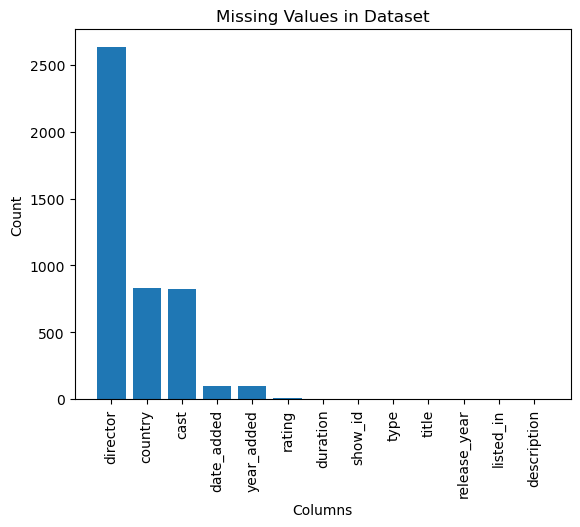

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)

plt.figure()
plt.bar(missing.index, missing.values)
plt.xticks(rotation=90)
plt.title("Missing Values in Dataset")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.show()

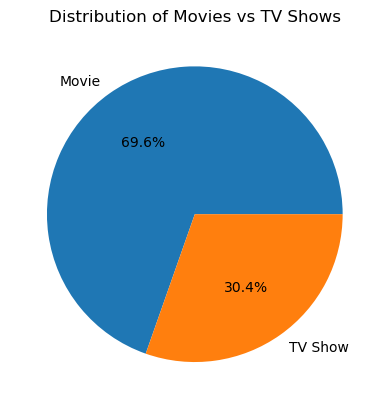

In [4]:
type_counts = df['type'].value_counts()

plt.figure()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%')
plt.title("Distribution of Movies vs TV Shows")
plt.show()

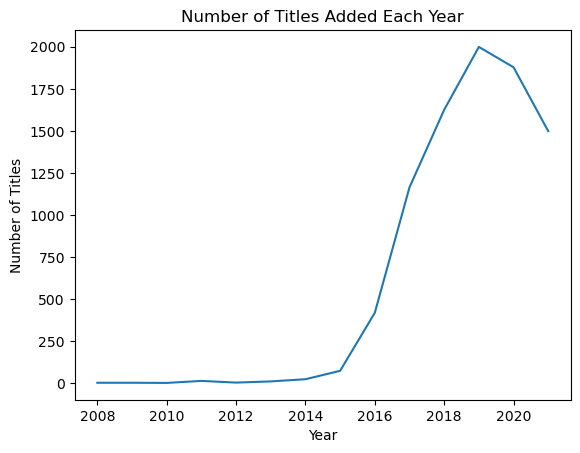

In [5]:
year_counts = df['year_added'].value_counts().sort_index()

plt.figure()
plt.plot(year_counts.index, year_counts.values)
plt.title("Number of Titles Added Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

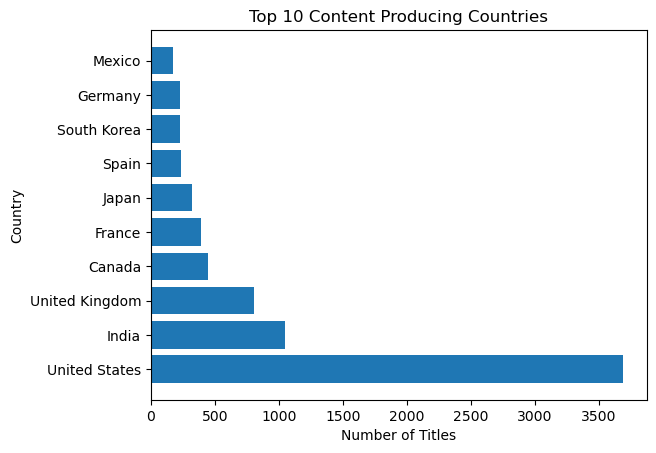

In [6]:
df['country'] = df['country'].str.split(',')
country_df = df.explode('country')
country_df['country'] = country_df['country'].str.strip()

top_countries = country_df['country'].value_counts().head(10)

plt.figure()
plt.barh(top_countries.index, top_countries.values)
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

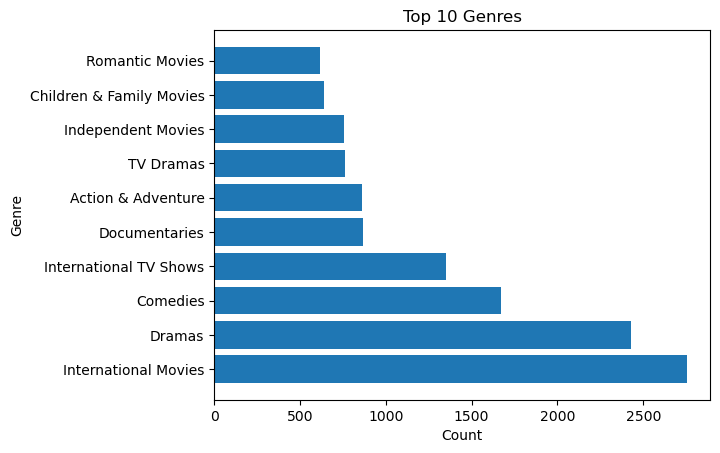

In [7]:
df['listed_in'] = df['listed_in'].str.split(',')
genre_df = df.explode('listed_in')
genre_df['listed_in'] = genre_df['listed_in'].str.strip()

top_genres = genre_df['listed_in'].value_counts().head(10)

plt.figure()
plt.barh(top_genres.index, top_genres.values)
plt.title("Top 10 Genres")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

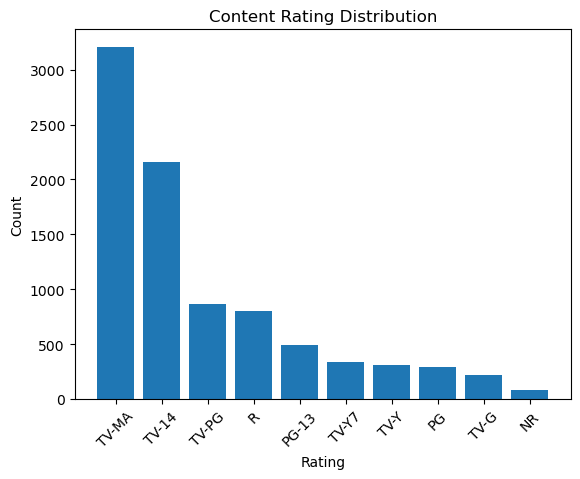

In [8]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure()
plt.bar(rating_counts.index, rating_counts.values)
plt.xticks(rotation=45)
plt.title("Content Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

C:\Users\meetr\AppData\Local\Temp\ipykernel_19944\3569456125.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_num'] = movies['duration'].str.extract('(\d+)')
C:\Users\meetr\AppData\Local\Temp\ipykernel_19944\3569456125.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_num'] = pd.to_numeric(movies['duration_num'], errors='coerce')


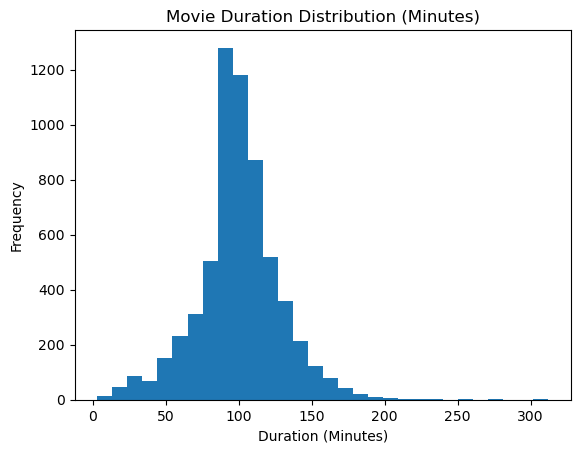

In [9]:
movies = df[df['type'] == 'Movie']

movies['duration_num'] = movies['duration'].str.extract('(\d+)')
movies['duration_num'] = pd.to_numeric(movies['duration_num'], errors='coerce')

plt.figure()
plt.hist(movies['duration_num'].dropna(), bins=30)
plt.title("Movie Duration Distribution (Minutes)")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

C:\Users\meetr\AppData\Local\Temp\ipykernel_19944\1144026335.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv['duration_num'] = tv['duration'].str.extract('(\d+)')
C:\Users\meetr\AppData\Local\Temp\ipykernel_19944\1144026335.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv['duration_num'] = pd.to_numeric(tv['duration_num'], errors='coerce')


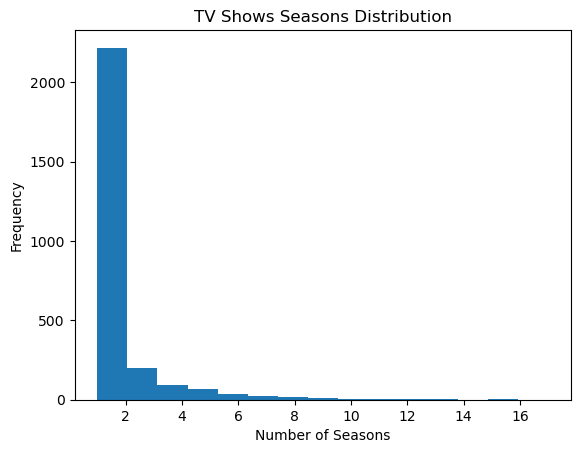

In [10]:
tv = df[df['type'] == 'TV Show']

tv['duration_num'] = tv['duration'].str.extract('(\d+)')
tv['duration_num'] = pd.to_numeric(tv['duration_num'], errors='coerce')

plt.figure()
plt.hist(tv['duration_num'].dropna(), bins=15)
plt.title("TV Shows Seasons Distribution")
plt.xlabel("Number of Seasons")
plt.ylabel("Frequency")
plt.show()

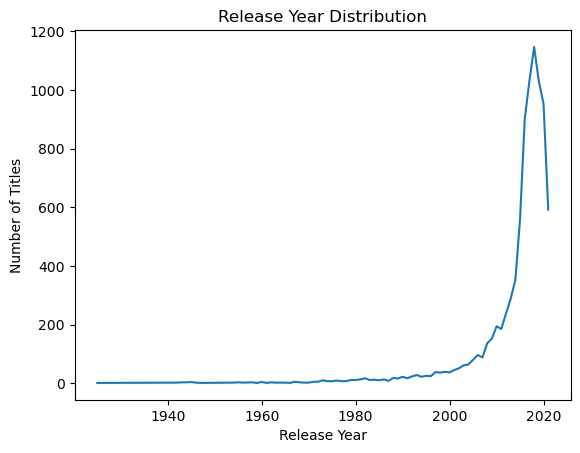

In [11]:
release_counts = df['release_year'].value_counts().sort_index()

plt.figure()
plt.plot(release_counts.index, release_counts.values)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

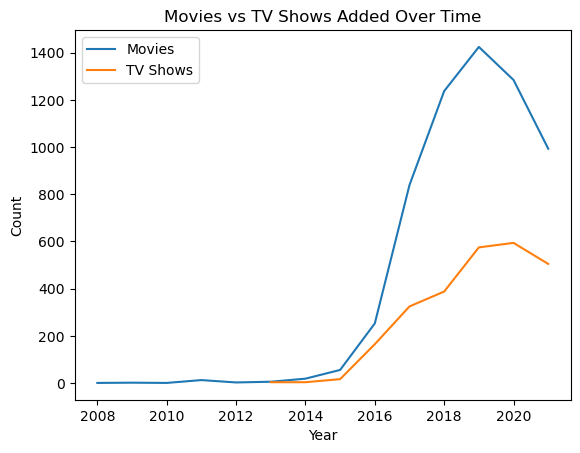

In [12]:
year_type = df.groupby(['year_added', 'type']).size().unstack()

plt.figure()
plt.plot(year_type.index, year_type['Movie'])
plt.plot(year_type.index, year_type['TV Show'])
plt.legend(['Movies', 'TV Shows'])
plt.title("Movies vs TV Shows Added Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()